## Step 1: Load the data

`Train.csv` is the E-Commerce Shipping dataset: 10,999 orders, 12 columns. The target is
`Reached.on.Time_Y.N`, where **1 = the order did NOT arrive on time** and 0 = it did.

The file has a header row, so `pd.read_csv()` reads it directly. Later steps import what they
need when they need it.

In [1]:
import pandas as pd

df = pd.read_csv('Train.csv')

print(df.shape)
df.head()

(10999, 12)


,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   10999 non-null  int64 
 1   Warehouse_block      10999 non-null  object
 2   Mode_of_Shipment     10999 non-null  object
 3   Customer_care_calls  10999 non-null  int64 
 4   Customer_rating      10999 non-null  int64 
 5   Cost_of_the_Product  10999 non-null  int64 
 6   Prior_purchases      10999 non-null  int64 
 7   Product_importance   10999 non-null  object
 8   Gender               10999 non-null  object
 9   Discount_offered     10999 non-null  int64 
 10  Weight_in_gms        10999 non-null  int64 
 11  Reached.on.Time_Y.N  10999 non-null  int64 
dtypes: int64(8), object(4)
memory usage: 1.0+ MB


## Step 2: Train / test split

The target is imbalanced - 6,563 late against 4,436 on time, roughly 60:40. A plain random split
can shift that ratio, so `stratify=y` keeps the same class balance in both halves. 80% train,
20% test, `random_state=42` so the split is reproducible.

`ID` is just a row number with no predictive value, so it is dropped from the features.

In [3]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['ID', 'Reached.on.Time_Y.N'])
y = df['Reached.on.Time_Y.N']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print('Train size:', X_train.shape, ' Test size:', X_test.shape)
print()
print('Train class ratio:')
print(y_train.value_counts(normalize=True))
print()
print('Test class ratio:')
print(y_test.value_counts(normalize=True))

Train size: (8799, 10)  Test size: (2200, 10)

Train class ratio:
Reached.on.Time_Y.N
1    0.596659
0    0.403341
Name: proportion, dtype: float64

Test class ratio:
Reached.on.Time_Y.N
1    0.596818
0    0.403182
Name: proportion, dtype: float64


## Step 3: One-hot encoding

Four columns are categorical: `Warehouse_block`, `Mode_of_Shipment`, `Product_importance`,
`Gender`. Naive Bayes needs numbers, so they are one-hot encoded.

**The encoder is fit on the training set only**, then applied to both halves. Fitting it on the
full dataset before splitting would let the test set influence the encoding - the same leakage
problem as splitting after preprocessing.

`handle_unknown='ignore'` means a category that appears only in the test set becomes all zeros
instead of raising an error.

In [4]:
from sklearn.preprocessing import OneHotEncoder

cat_cols = ['Warehouse_block', 'Mode_of_Shipment', 'Product_importance', 'Gender']

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoder.fit(X_train[cat_cols])

train_encoded = pd.DataFrame(
    encoder.transform(X_train[cat_cols]),
    columns=encoder.get_feature_names_out(cat_cols),
    index=X_train.index
)
test_encoded = pd.DataFrame(
    encoder.transform(X_test[cat_cols]),
    columns=encoder.get_feature_names_out(cat_cols),
    index=X_test.index
)

X_train_final = pd.concat([X_train.drop(columns=cat_cols), train_encoded], axis=1)
X_test_final = pd.concat([X_test.drop(columns=cat_cols), test_encoded], axis=1)

print(X_train_final.shape, X_test_final.shape)
X_train_final.head()

(8799, 19) (2200, 19)


,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Warehouse_block_A,Warehouse_block_B,Warehouse_block_C,Warehouse_block_D,Warehouse_block_F,Mode_of_Shipment_Flight,Mode_of_Shipment_Road,Mode_of_Shipment_Ship,Product_importance_high,Product_importance_low,Product_importance_medium,Gender_F,Gender_M
7920,4,1,261,2,9,4158,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
1529,3,3,162,2,26,1659,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
10521,3,2,221,2,9,4466,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
9558,3,5,157,4,2,4640,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
968,2,5,272,2,24,3638,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


## Step 4: Train the model

All 19 features are numeric after encoding. Three of them - `Cost_of_the_Product`,
`Discount_offered`, `Weight_in_gms` - are continuous.

### Which Naive Bayes?

`BernoulliNB` expects binary features and `MultinomialNB` expects counts, like word frequencies.
Neither describes this data: the features that matter most here are continuous numbers.
`GaussianNB` assumes each feature is normally distributed within a class, which is the closest
fit of the three.

In [5]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

model = GaussianNB()
model.fit(X_train_final, y_train)

y_pred = model.predict(X_test_final)

print('Accuracy:', accuracy_score(y_test, y_pred))
print()
print('Confusion matrix:')
print(confusion_matrix(y_test, y_pred))
print()
print(classification_report(y_test, y_pred))

Accuracy: 0.644090909090909

Confusion matrix:
[[861  26]
 [757 556]]

              precision    recall  f1-score   support

           0       0.53      0.97      0.69       887
           1       0.96      0.42      0.59      1313

    accuracy                           0.64      2200
   macro avg       0.74      0.70      0.64      2200
weighted avg       0.78      0.64      0.63      2200



## Step 5: What the model is actually doing

Three plots: the class balance, `Discount_offered` split by class, and the confusion matrix.

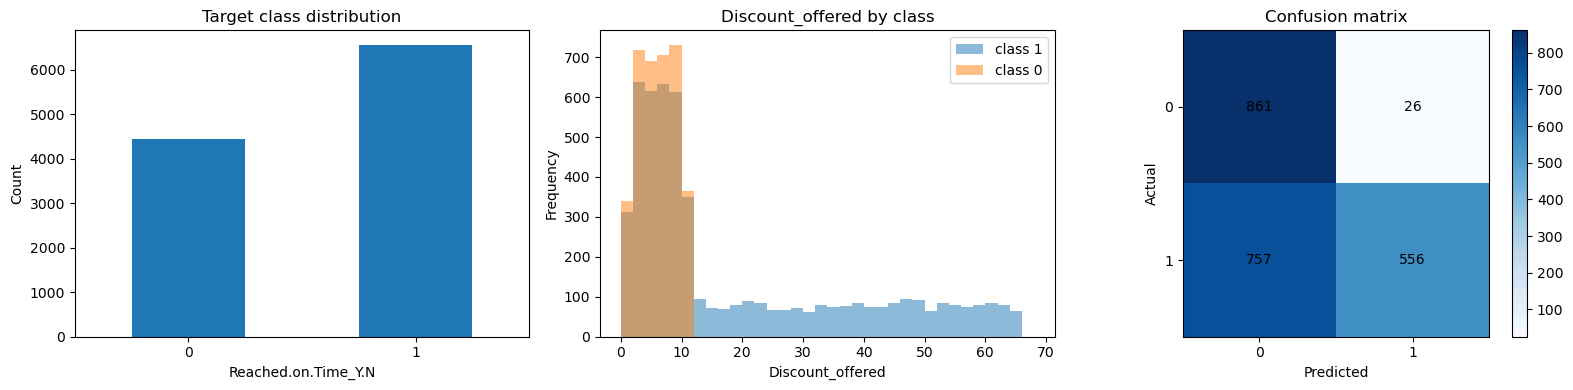

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Class distribution
y.value_counts().sort_index().plot(kind='bar', ax=axes[0], rot=0)
axes[0].set_title('Target class distribution')
axes[0].set_xlabel('Reached.on.Time_Y.N')
axes[0].set_ylabel('Count')

# 2. Discount_offered by class
# the same bin edges are used for both classes so the two histograms line up,
# and class 1 is drawn first so the smaller class 0 stays visible on top
bins = range(0, 70, 2)
for cls in [1, 0]:
    X_train.loc[y_train == cls, 'Discount_offered'].plot(
        kind='hist', bins=bins, alpha=0.5, ax=axes[1], label=f'class {cls}'
    )
axes[1].set_title('Discount_offered by class')
axes[1].set_xlabel('Discount_offered')
axes[1].legend()

# 3. Confusion matrix heatmap
cm = confusion_matrix(y_test, y_pred)
im = axes[2].imshow(cm, cmap='Blues')
axes[2].set_title('Confusion matrix')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')
axes[2].set_xticks([0, 1])
axes[2].set_yticks([0, 1])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        axes[2].text(j, i, cm[i, j], ha='center', va='center')
fig.colorbar(im, ax=axes[2])

plt.tight_layout()
plt.show()

## Step 6: Is the model better than guessing?

64% accuracy sounds reasonable until you check what you get for free. The classes are 60:40, so
always predicting "late" already gets about 60% right. `DummyClassifier(strategy='most_frequent')`
makes that comparison explicit.

In [7]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train_final, y_train)
baseline_acc = accuracy_score(y_test, dummy.predict(X_test_final))
nb_acc = accuracy_score(y_test, y_pred)

print(f'Majority-class baseline : {baseline_acc:.4f}')
print(f'GaussianNB              : {nb_acc:.4f}')
print(f'Improvement over baseline : {(nb_acc - baseline_acc) * 100:+.2f} percentage points')

Majority-class baseline : 0.5968
GaussianNB              : 0.6441
Improvement over baseline : +4.73 percentage points


## Step 7: What the numbers say

The majority-class baseline gets 59.68% and the model gets 64.41%, so it beats guessing - by
4.73 percentage points.

The confusion matrix is the more interesting part. Recall for class 1 (late) is 0.42, meaning the
model misses more than half of the orders that actually arrived late, while class 0 recall is 0.97.
It predicts "on time" too readily. Whether that is the costly direction to be wrong in depends on
what the company does with a warning, and the accuracy figure on its own says nothing about it.

The next notebook puts a neural network on the same split to see whether a more flexible model
closes that gap.